# LokaSense Training Notebook

This notebook is the maintained training entry point for the project.
It rebuilds the pipeline in notebook form so the outputs live inside the cells instead of a detached terminal session.
It covers raw data inspection, Indonesian-first preprocessing, weak labeling, split creation, model training, and PyTorch test evaluation.


## Notebook Flow

1. Check the training environment and available hardware.
2. Inspect the currently available raw datasets.
3. Run lightweight EDA on language mix, sources, and market coverage.
4. Rebuild the scraped bootstrap datasets used by the downstream pipeline.
5. Regenerate weak labels and train/validation/test splits.
6. Train the signal model and the NER model.
7. Evaluate both checkpoints directly from the saved PyTorch model folders.


In [1]:
import json
import os
import platform
import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "01_data_collection").exists(), "Please run this notebook from the repo root."
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common.bootstrap_utils import build_ner_bootstrap_rows, build_signal_bootstrap_rows
from common.text_normalization import language_scores, strip_emoji

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

SCRAPING_PYTHON = REPO_ROOT / ".venv_scraping" / "bin" / "python"
TIKTOK_SOURCE_FILE = REPO_ROOT / "data" / "social_media" / "tiktok_data.csv"
FORCE_TIKTOK_REFRESH = False
RUN_TIKTOK_REFRESH = FORCE_TIKTOK_REFRESH or (not TIKTOK_SOURCE_FILE.exists())
RESET_TIKTOK_SOURCE = FORCE_TIKTOK_REFRESH
TIKTOK_REFRESH_ARGS = [
    str(SCRAPING_PYTHON if SCRAPING_PYTHON.exists() else Path(sys.executable)),
    "01_data_collection/collect_social_bootstrap.py",
    "--platform", "tiktok",
    "--max-queries", "80",
    "--max-per-query", "8",
    "--max-saved-rows", "80",
    "--headless",
    "--query-delay", "0.5",
]

SIGNAL_LABELS = [
    "NEUTRAL",
    "DEMAND_UNMET",
    "DEMAND_PRESENT",
    "SUPPLY_SIGNAL",
    "COMPETITION_HIGH",
    "COMPLAINT",
    "TREND",
]


def run_command(args, cwd=REPO_ROOT, extra_env=None):
    env = os.environ.copy()
    if extra_env:
        env.update(extra_env)
    print("$", " ".join(map(str, args)))
    completed = subprocess.run(
        args,
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}: {' '.join(map(str, args))}")
    return completed


def classify_language(text: str) -> str:
    scores = language_scores(str(text))
    id_score = scores["id"] + scores["slang"]
    en_score = scores["en"]
    if id_score == 0 and en_score == 0:
        return "unclear"
    if id_score >= en_score:
        return "indonesian_dominant"
    return "english_dominant"


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def reset_tiktok_artifacts():
    for path in [
        REPO_ROOT / "data" / "social_media" / "tiktok_data.csv",
        REPO_ROOT / "data" / "scraped" / "checkpoints" / "tiktok_crawl_state.json",
    ]:
        if path.exists():
            path.unlink()
            print(f"Removed {path}")


def clean_preview_frame(df: pd.DataFrame) -> pd.DataFrame:
    preview = df.copy()
    for column in preview.columns:
        if pd.api.types.is_object_dtype(preview[column]):
            preview[column] = preview[column].fillna("").astype(str).map(strip_emoji)
    return preview


def validate_scraping_runtime():
    scrape_python = Path(TIKTOK_REFRESH_ARGS[0])
    if not scrape_python.exists():
        raise FileNotFoundError(f"Scraping Python runtime not found at {scrape_python}")
    probe = subprocess.run(
        [str(scrape_python), "-c", "import scrapling; print(scrapling.__version__)"],
        cwd=str(REPO_ROOT),
        text=True,
        capture_output=True,
        check=False,
    )
    if probe.returncode != 0:
        raise RuntimeError(probe.stderr or probe.stdout or "Failed to validate Scrapling runtime")
    print(f"Scraping runtime ready: {scrape_python}")


environment_summary = {
    "python_executable": sys.executable,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu_only",
}
display(pd.DataFrame([environment_summary]))


,python_executable,python_version,platform,torch_version,cuda_available,cuda_device
0,/home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python,3.14.3,Linux-6.12.52_1-x86_64-with-glibc2.41,2.11.0+cu130,True,NVIDIA GeForce RTX 4050 Laptop GPU


The setup cell establishes the repo root, helper functions, and environment summary.
If you reopen this notebook later, rerunning that cell is the quickest way to restore the working state.


In [2]:
raw_files = {
    "tiktok": REPO_ROOT / "data" / "social_media" / "tiktok_data.csv",
    "instagram": REPO_ROOT / "data" / "social_media" / "instagram_data.csv",
    "x": REPO_ROOT / "data" / "social_media" / "x_data.csv",
    "google_maps": REPO_ROOT / "data" / "social_media" / "gmaps_reviews.csv",
}

if RUN_TIKTOK_REFRESH:
    validate_scraping_runtime()
    if RESET_TIKTOK_SOURCE:
        reset_tiktok_artifacts()
    run_command(TIKTOK_REFRESH_ARGS)
else:
    print("Skipping TikTok refresh and reusing the current raw CSV files.")

raw_counts = []
for source, path in raw_files.items():
    if path.exists():
        df = pd.read_csv(path)
        raw_counts.append({"source": source, "rows": len(df), "path": str(path)})
raw_counts_df = pd.DataFrame(raw_counts).sort_values("rows", ascending=False)
display(raw_counts_df)


Skipping TikTok refresh and reusing the current raw CSV files.


,source,rows,path
1,google_maps,5110,/home/parasite/Project/Competition/UGM_HACKATHON/data/social_media/gmaps_reviews.csv
0,tiktok,64,/home/parasite/Project/Competition/UGM_HACKATHON/data/social_media/tiktok_data.csv


This cell is the notebook-friendly replacement for the old background scraping step.
If a TikTok source file already exists, the notebook reuses it by default so reruns stay practical.
If you want a fresh scrape, set `FORCE_TIKTOK_REFRESH = True` in the setup cell.


,source,rows,non_empty_text_rows,avg_text_length,indonesian_dominant,english_dominant,unclear
1,google_maps,5110,5110,244.9,79,4835,196
0,tiktok,64,64,292.7,60,3,1


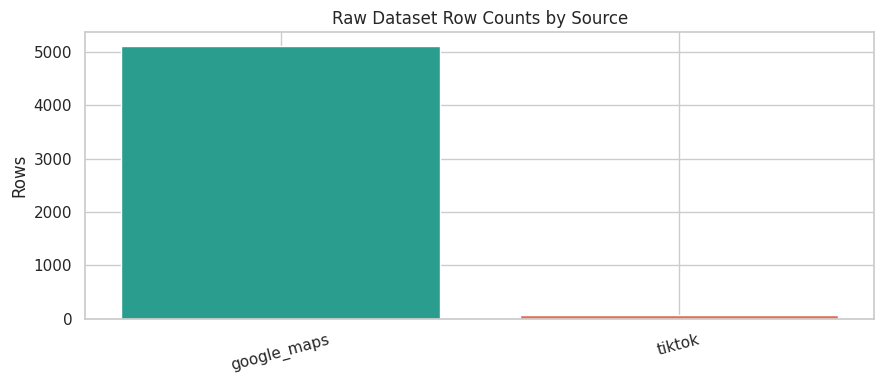

,source,text,city,area_hint,business_hint,query
0,tiktok,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free...",Malang,Lowokwaru,mie,mie buka cabang di Lowokwaru Malang
1,tiktok,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,Malang,Lowokwaru,mie,mie buka cabang di Lowokwaru Malang
2,tiktok,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,Malang,Lowokwaru,mie,mie buka cabang di Lowokwaru Malang
3,google_maps,"I'm sorry but I'm so not impressed.\nMy chicken is cold, batter is stoney, can't really taste the chicken meat.\nRic...",Malang,Lowokwaru,ayam geprek,NaN
4,google_maps,"It was okay but not great. I ordered sambal matah variant and they gave me a full bowl (small bowl) of sambal matah,...",Malang,Lowokwaru,ayam geprek,NaN
5,google_maps,The food taste good with several options for sambal. The place is quite small so i don't recommend to come with larg...,Malang,Lowokwaru,ayam geprek,NaN


In [3]:
eda_rows = []
sample_frames = []

for source, path in raw_files.items():
    if not path.exists():
        continue

    df = pd.read_csv(path)
    text_col = "raw_text" if "raw_text" in df.columns else "text"
    texts = df[text_col].fillna("").astype(str)
    language_mix = Counter(classify_language(text) for text in texts if text.strip())

    eda_rows.append(
        {
            "source": source,
            "rows": len(df),
            "non_empty_text_rows": int((texts.str.len() > 0).sum()),
            "avg_text_length": round(float(texts.str.len().mean()), 1),
            "indonesian_dominant": language_mix.get("indonesian_dominant", 0),
            "english_dominant": language_mix.get("english_dominant", 0),
            "unclear": language_mix.get("unclear", 0),
        }
    )

    preview_cols = [col for col in ["text", "city", "area_hint", "business_hint", "query"] if col in df.columns]
    if preview_cols:
        preview = clean_preview_frame(df[preview_cols].head(3).copy())
        preview.insert(0, "source", source)
        sample_frames.append(preview)

eda_df = pd.DataFrame(eda_rows).sort_values("rows", ascending=False)
display(eda_df)

plt.figure(figsize=(9, 4))
plt.bar(eda_df["source"], eda_df["rows"], color=["#2a9d8f", "#e76f51", "#f4a261", "#457b9d"][: len(eda_df)])
plt.title("Raw Dataset Row Counts by Source")
plt.ylabel("Rows")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

if sample_frames:
    display(pd.concat(sample_frames, ignore_index=True))


The EDA cell answers two practical questions before we train anything:

- Do we actually have Indonesian-domain text available right now?
- Which sources are dominating the pipeline?

That matters here because the repo previously leaned too hard on English Google Maps reviews, which is a poor fit for an IndoBERT-centered classifier.


In [4]:
signal_rows = build_signal_bootstrap_rows()
signal_bootstrap_df = pd.DataFrame(signal_rows)
signal_bootstrap_path = REPO_ROOT / "data" / "scraped" / "signal_bootstrap.csv"
signal_bootstrap_df.to_csv(signal_bootstrap_path, index=False)

ner_rows = build_ner_bootstrap_rows(signal_rows)
ner_bootstrap_path = REPO_ROOT / "data" / "scraped" / "ner_bootstrap.jsonl"
ner_bootstrap_path.parent.mkdir(parents=True, exist_ok=True)
with open(ner_bootstrap_path, "w", encoding="utf-8") as handle:
    for row in ner_rows:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"signal_bootstrap_path = {signal_bootstrap_path}")
print(f"ner_bootstrap_path = {ner_bootstrap_path}")
print(f"signal_rows = {len(signal_bootstrap_df)}")
print(f"ner_rows = {len(ner_rows)}")

display(clean_preview_frame(signal_bootstrap_df.head(10)))
display(
    signal_bootstrap_df.groupby(["platform", "city"])["text"].count().rename("rows").reset_index().sort_values("rows", ascending=False)
)

candidate_counts = [
    len(row["candidate_spans"]) for row in ner_rows
]
display(
    pd.DataFrame(
        {
            "candidate_span_min": [int(np.min(candidate_counts)) if candidate_counts else 0],
            "candidate_span_mean": [round(float(np.mean(candidate_counts)), 2) if candidate_counts else 0.0],
            "candidate_span_max": [int(np.max(candidate_counts)) if candidate_counts else 0],
        }
    )
)


signal_bootstrap_path = /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/signal_bootstrap.csv
ner_bootstrap_path = /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/ner_bootstrap.jsonl
signal_rows = 99
ner_rows = 99


,text,source,platform,url,timestamp,area_hint,city,business_hint,query,provenance_split
0,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free...",tiktok_scrapling,tiktok,https://www.tiktok.com/@mieayamkeraton/video/7624395493249993991,2026-04-03T05:08:39Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,train
1,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7539804950214364422,2025-08-18T06:14:14Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,test
2,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7505634284594531590,2025-05-18T04:14:29Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,test
3,mia ayam langganan siapa nih kuliner malang kulinermalang mie mieayam,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7589989139756354834,2025-12-31T11:54:20Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,train
4,cocok banget pas malang lagi ujan kulinermalang kulinermalangraya mahasiswamalang pangsitmiesenja pangsitmalang,tiktok_scrapling,tiktok,https://www.tiktok.com/@cowokopian/video/7580315965750119700,2025-12-05T10:17:38Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,test
5,"menu ramyeon tray topping baru haus kali ini benar benerrr enakkk, dan perlu dicoba untuk add on mozzarella nya!!! s...",tiktok_scrapling,tiktok,https://www.tiktok.com/@keiydipieee/video/7520165487515356422,2025-06-26T08:03:01Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,train
6,"mie ayam porsi barbar, harga mulai 10 ribu saja mie ayam sam edy jl. pacar air no.15, jatimulyo, kec. lowokwaru, kot...",tiktok_scrapling,tiktok,https://www.tiktok.com/@dolanyok.malang/video/7482292622653001015,2025-03-16T06:36:58Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,validation
7,"mie marem jaya jl. pasar tawangmangu no.c 26, lowokwaru, kec. lowokwaru, kota malang. kulinermalang malang mahasiswa...",tiktok_scrapling,tiktok,https://www.tiktok.com/@tiwipes/video/7623663078223138069,2026-04-01T05:46:29Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,train
8,"rasanya nikmatt, porsi buanyakk sangat untuk kalian yang suka chinese food yukk cobain depot fyp makananviral malang...",tiktok_scrapling,tiktok,https://www.tiktok.com/@temanseri/video/7603713221039738133,2026-02-06T11:30:47Z,Lowokwaru,Malang,kedai makan,kedai makan kebanyakan di lowokwaru malang,test
9,warung ndeso mas gendon porsi portugal banget kulinertiktok kulinermalang malangkuliner kulinermahasiswa fypage,tiktok_scrapling,tiktok,https://www.tiktok.com/@rudykurniawan93/video/7570959913338408213,2025-11-10T05:11:18Z,Lowokwaru,Malang,kedai makan,kedai makan kebanyakan di lowokwaru malang,train


,platform,city,rows
7,tiktok,Surabaya,20
8,tiktok,Yogyakarta,16
6,tiktok,Malang,15
1,google_maps,Malang,12
3,google_maps,Surabaya,8
4,google_maps,Yogyakarta,8
0,google_maps,Bandung,7
2,google_maps,Semarang,7
5,tiktok,Bandung,6


,candidate_span_min,candidate_span_mean,candidate_span_max
0,0,2.06,9


This preprocessing stage rebuilds the two scraped bootstrap artifacts the rest of the repo expects:

- `signal_bootstrap.csv` for market-signal classification text
- `ner_bootstrap.jsonl` for weak location/business spans

The main change from the older pipeline is that the bootstrap is now filtered toward Indonesian-like text before it ever reaches training.


In [5]:
run_command([sys.executable, "03_signal_model/dataset/weak_label.py"])
weak_labeled_path = REPO_ROOT / "data" / "labeled" / "weak_labeled.csv"
weak_df = pd.read_csv(weak_labeled_path)

weak_counts = (
    weak_df["signal"]
    .value_counts(dropna=False)
    .rename_axis("signal")
    .reset_index(name="rows")
)
display(weak_counts)
display(weak_df[["text", "signal", "confidence", "source"]].head(12))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/dataset/weak_label.py
 Weak Labeling Pipeline — 7-Class Market Signal

Loading raw text data...
  Loaded scraped bootstrap: 99 texts

  Total texts loaded: 99

Applying weak labeling rules...

Signal Distribution:
  DEMAND_PRESENT            35  ( 35.4%)  █████████████████
  NEUTRAL                   20  ( 20.2%)  ██████████
  SUPPLY_SIGNAL             17  ( 17.2%)  ████████
  TREND                     16  ( 16.2%)  ████████
  DEMAND_UNMET               8  (  8.1%)  ████
  COMPLAINT                  2  (  2.0%)  █
  COMPETITION_HIGH           1  (  1.0%)  

  High confidence (≥0.8): 21 (21.2%)
  Needs review: 78 (78.8%)

Saved 99 labeled texts to /home/parasite/Project/Competition/UGM_HACKATHON/data/labeled/weak_labeled.csv
  Summary saved to /home/parasite/Project/Competition/UGM_HACKATHON/data/labeled/weak_label_summary.json



,signal,rows
0,DEMAND_PRESENT,35
1,NEUTRAL,20
2,SUPPLY_SIGNAL,17
3,TREND,16
4,DEMAND_UNMET,8
5,COMPLAINT,2
6,COMPETITION_HIGH,1


,text,signal,confidence,source
0,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free...",SUPPLY_SIGNAL,0.6,tiktok_scrapling
1,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,SUPPLY_SIGNAL,0.6,tiktok_scrapling
2,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,SUPPLY_SIGNAL,0.6,tiktok_scrapling
3,mia ayam langganan siapa nih kuliner malang kulinermalang mie mieayam,DEMAND_PRESENT,0.6,tiktok_scrapling
4,cocok banget pas malang lagi ujan kulinermalang kulinermalangraya mahasiswamalang pangsitmiesenja pangsitmalang,SUPPLY_SIGNAL,0.6,tiktok_scrapling
5,"menu ramyeon tray topping baru haus kali ini benar benerrr enakkk, dan perlu dicoba untuk add on mozzarella nya!!! s...",SUPPLY_SIGNAL,0.6,tiktok_scrapling
6,"mie ayam porsi barbar, harga mulai 10 ribu saja mie ayam sam edy jl. pacar air no.15, jatimulyo, kec. lowokwaru, kot...",TREND,0.8,tiktok_scrapling
7,"mie marem jaya jl. pasar tawangmangu no.c 26, lowokwaru, kec. lowokwaru, kota malang. kulinermalang malang mahasiswa...",DEMAND_PRESENT,0.8,tiktok_scrapling
8,"rasanya nikmatt, porsi buanyakk sangat untuk kalian yang suka chinese food yukk cobain depot fyp makananviral malang...",TREND,0.8,tiktok_scrapling
9,warung ndeso mas gendon porsi portugal banget kulinertiktok kulinermalang malangkuliner kulinermahasiswa fypage,TREND,0.8,tiktok_scrapling


Weak labels are only a bootstrap layer, not the final truth.
This cell is still worth inspecting closely because it tells you which classes the current scrape can actually support and which ones are still data-scarce.


In [6]:
run_command([sys.executable, "03_signal_model/dataset/split.py"])
run_command([sys.executable, "02_ner_model/dataset/prepare.py"])

signal_split_paths = {
    "train": REPO_ROOT / "train_data" / "signal_train.csv",
    "validation": REPO_ROOT / "train_data" / "signal_val.csv",
    "test": REPO_ROOT / "test_data" / "signal_test.csv",
}

signal_distribution_frames = []
for split_name, split_path in signal_split_paths.items():
    split_df = pd.read_csv(split_path)
    counts = split_df["final_signal"].value_counts().rename(split_name)
    signal_distribution_frames.append(counts)
signal_distribution_df = pd.concat(signal_distribution_frames, axis=1).fillna(0).astype(int)
display(signal_distribution_df)

with open(REPO_ROOT / "train_data" / "ner_train.json", "r", encoding="utf-8") as handle:
    ner_train = json.load(handle)
with open(REPO_ROOT / "train_data" / "ner_val.json", "r", encoding="utf-8") as handle:
    ner_val = json.load(handle)
with open(REPO_ROOT / "test_data" / "ner_test.json", "r", encoding="utf-8") as handle:
    ner_test = json.load(handle)

ner_label_counts = Counter(tag for row in ner_train for tag in row["ner_tags"])
display(pd.DataFrame([{"split": "train", "rows": len(ner_train)}, {"split": "validation", "rows": len(ner_val)}, {"split": "test", "rows": len(ner_test)}]))
display(pd.DataFrame(sorted(ner_label_counts.items()), columns=["tag", "rows"]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/dataset/split.py


 Creating Leakage-Proof Data Splits (Signal)
  Loaded 99 weak labeled texts.
  Loaded 1000 Gemini pseudo-labeled texts.
  Keeping rare classes in train only: ['COMPETITION_HIGH', 'COMPLAINT']

  Splitting data (Stratified 70/15/15)...

Splits saved successfully:
   Train :     69 (69.7%) -> /home/parasite/Project/Competition/UGM_HACKATHON/train_data/signal_train.csv
   Val   :     15 (15.2%) -> /home/parasite/Project/Competition/UGM_HACKATHON/train_data/signal_val.csv
   Test  :     15 (15.2%) -> /home/parasite/Project/Competition/UGM_HACKATHON/test_data/signal_test.csv
   Leakage test: 0 overlapping rows between train and test.

 Creating Leakage-Proof Data Splits (NER)
  IndoLEM data not found. Run setup_datasets.py first.

Leakage-proof data split phase complete.
  You can now begin model training without data contamination.

$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 02_ner_model/dataset/prepare.py
 NER Dataset Preparation — IndoLEM
  Added scraped weak NER

,train,validation,test
final_signal,,,
DEMAND_PRESENT,24,6,5
NEUTRAL,14,3,3
TREND,11,2,3
SUPPLY_SIGNAL,11,3,3
DEMAND_UNMET,6,1,1
COMPLAINT,2,0,0
COMPETITION_HIGH,1,0,0


,split,rows
0,train,3282
1,validation,400
2,test,682


,tag,rows
0,B-LOC,1738
1,B-ORG,2088
2,B-PER,2429
3,I-LOC,902
4,I-ORG,1499
5,I-PER,1419
6,O,63708


At this stage the notebook has reproduced the train/validation/test assets that the standalone scripts use.
The signal split table is the quickest sanity check for class sparsity, while the NER tag table confirms that the label cleanup reduced the schema to the entities we actually want to model.


In [7]:
import json
from pathlib import Path

from seqeval.metrics import classification_report as seq_classification_report
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_signal_checkpoint(model_dir: Path, test_path: Path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(device)
    model.eval()

    test_df = pd.read_csv(test_path).dropna(subset=["text", "final_signal"]).copy()
    label2id = {label: idx for idx, label in enumerate(SIGNAL_LABELS)}
    id2label = {idx: label for label, idx in label2id.items()}

    batch_size = 16
    preds = []
    probs = []
    texts = test_df["text"].astype(str).tolist()
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = model(**encoded).logits
            batch_probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds.extend(batch_probs.argmax(axis=-1).tolist())
        probs.extend(batch_probs.tolist())

    true_ids = test_df["final_signal"].map(label2id).tolist()
    report = classification_report(
        true_ids,
        preds,
        labels=list(range(len(SIGNAL_LABELS))),
        target_names=SIGNAL_LABELS,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T

    cm = confusion_matrix(true_ids, preds, labels=list(range(len(SIGNAL_LABELS))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS)
    plt.title("Signal Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    preview_rows = []
    for text, pred_id, prob in zip(texts[:10], preds[:10], probs[:10]):
        ranked = np.argsort(prob)[::-1][:3]
        preview_rows.append(
            {
                "text": text[:120],
                "top_label": id2label[pred_id],
                "top_probability": round(float(prob[pred_id]), 4),
                "runner_up": id2label[int(ranked[1])] if len(ranked) > 1 else "",
            }
        )
    preview_df = pd.DataFrame(preview_rows)

    metrics_path = REPO_ROOT / "logs" / "signal_test_metrics_pytorch.json"
    metrics_payload = {
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "accuracy": float(report["accuracy"]),
        "samples": int(len(test_df)),
    }
    with open(metrics_path, "w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)

    return report_df, preview_df, metrics_payload


def regex_tokens(text: str):
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def predict_ner_tags(model, tokenizer, text: str):
    device = next(model.parameters()).device
    tokens = regex_tokens(text)
    encoded = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=128, return_tensors="pt")
    word_ids = encoded.word_ids(batch_index=0)
    encoded = {key: value.to(device) for key, value in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits
    pred_ids = torch.argmax(logits, dim=-1)[0].cpu().tolist()

    aligned = []
    previous_word_id = None
    for token_index, word_id in enumerate(word_ids):
        if word_id is None or word_id == previous_word_id:
            previous_word_id = word_id
            continue
        aligned.append((tokens[word_id], model.config.id2label[pred_ids[token_index]]))
        previous_word_id = word_id
    return aligned


def extract_entities_from_tags(aligned_tags):
    entities = []
    current_tokens = []
    current_label = None
    for token, tag in aligned_tags:
        if tag.startswith("B-"):
            if current_tokens:
                entities.append({"entity": " ".join(current_tokens), "label": current_label})
            current_tokens = [token]
            current_label = tag[2:]
        elif tag.startswith("I-") and current_tokens and current_label == tag[2:]:
            current_tokens.append(token)
        else:
            if current_tokens:
                entities.append({"entity": " ".join(current_tokens), "label": current_label})
            current_tokens = []
            current_label = None
    if current_tokens:
        entities.append({"entity": " ".join(current_tokens), "label": current_label})
    return entities


def evaluate_ner_checkpoint(model_dir: Path, test_path: Path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForTokenClassification.from_pretrained(str(model_dir)).to(device)
    model.eval()

    test_data = read_json(test_path)
    true_labels = []
    pred_labels = []
    preview_rows = []

    for item in test_data:
        text = " ".join(item["tokens"])
        aligned_pred = predict_ner_tags(model, tokenizer, text)
        predicted_tags = [tag for _, tag in aligned_pred]
        min_len = min(len(item["ner_tags"]), len(predicted_tags))
        if min_len == 0:
            continue
        gold = item["ner_tags"][:min_len]
        pred = predicted_tags[:min_len]
        true_labels.append(gold)
        pred_labels.append(pred)
        if len(preview_rows) < 8:
            preview_rows.append(
                {
                    "text": text[:120],
                    "gold_entities": extract_entities_from_tags(list(zip(item["tokens"][:min_len], gold))),
                    "pred_entities": extract_entities_from_tags(list(zip(item["tokens"][:min_len], pred))),
                }
            )

    report_dict = seq_classification_report(true_labels, pred_labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).T
    metrics_path = REPO_ROOT / "logs" / "ner_test_metrics_pytorch.json"
    metrics_payload = {
        "micro_f1": float(report_dict["micro avg"]["f1-score"]),
        "samples": int(len(true_labels)),
    }
    with open(metrics_path, "w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)

    preview_df = pd.DataFrame(preview_rows)
    return report_df, preview_df, metrics_payload


/home/parasite/Project/Competition/UGM_HACKATHON/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The helper cell above keeps the later training sections cleaner by handling PyTorch checkpoint evaluation directly in the notebook.
That lets us show the final reports in-place without depending on the ONNX export path.


In [8]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

run_command([sys.executable, "03_signal_model/modelling/train.py"])
signal_metrics = read_json(REPO_ROOT / "logs" / "signal_training_metrics.json")
display(pd.DataFrame([signal_metrics]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/modelling/train.py


 Signal Classifier Training — LokaSense
  Train: 69 | Val: 15
  Class weights: {'NEUTRAL': '0.70', 'DEMAND_UNMET': '1.64', 'DEMAND_PRESENT': '0.41', 'SUPPLY_SIGNAL': '0.90', 'COMPETITION_HIGH': '9.86', 'COMPLAINT': '4.93', 'TREND': '0.90'}
{'eval_loss': 1.8168572187423706, 'eval_macro_f1': 0.07518796992481203, 'eval_f1_NEUTRAL': 0.0, 'eval_f1_DEMAND_UNMET': 0.0, 'eval_f1_DEMAND_PRESENT': 0.5263157894736842, 'eval_f1_SUPPLY_SIGNAL': 0.0, 'eval_f1_COMPETITION_HIGH': 0.0, 'eval_f1_COMPLAINT': 0.0, 'eval_f1_TREND': 0.0, 'eval_runtime': 0.0806, 'eval_samples_per_second': 186.123, 'eval_steps_per_second': 49.633, 'epoch': 1.0}
{'eval_loss': 1.751047134399414, 'eval_macro_f1': 0.0757020757020757, 'eval_f1_NEUTRAL': 0.2222222222222222, 'eval_f1_DEMAND_UNMET': 0.0, 'eval_f1_DEMAND_PRESENT': 0.3076923076923077, 'eval_f1_SUPPLY_SIGNAL': 0.0, 'eval_f1_COMPETITION_HIGH': 0.0, 'eval_f1_COMPLAINT': 0.0, 'eval_f1_TREND': 0.0, 'eval_runtime': 0.0673, 'eval_samples_per_second': 222.876, 'eval_steps_per_

,training_time_sec,train_loss,best_metric,epochs_trained,model_name,train_samples,val_samples,eval_history
0,122.380045,1.301307,0.119048,7.0,indobenchmark/indobert-base-p1,69,15,"[{'eval_loss': 1.8168572187423706, 'eval_macro_f1': 0.07518796992481203, 'eval_f1_NEUTRAL': 0.0, 'eval_f1_DEMAND_UNM..."


The signal training cell runs the current IndoBERT trainer exactly as the repo would from the terminal.
The metrics table below it is the compact summary you can scan without digging through the raw trainer log.


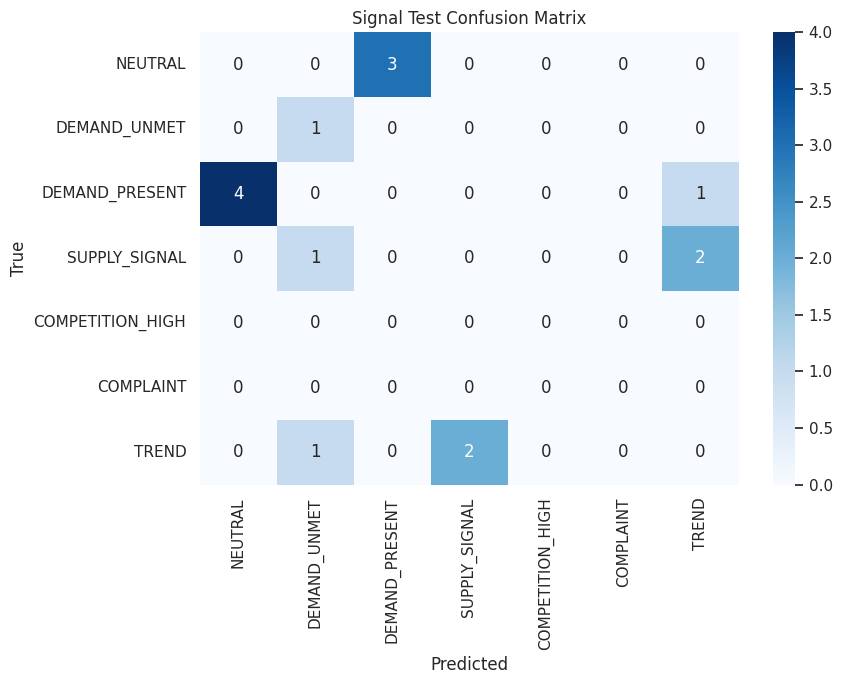

,precision,recall,f1-score,support
NEUTRAL,0.000000,0.000000,0.000000,3.000000
DEMAND_UNMET,0.333333,1.000000,0.500000,1.000000
DEMAND_PRESENT,0.000000,0.000000,0.000000,5.000000
SUPPLY_SIGNAL,0.000000,0.000000,0.000000,3.000000
COMPETITION_HIGH,0.000000,0.000000,0.000000,0.000000
COMPLAINT,0.000000,0.000000,0.000000,0.000000
TREND,0.000000,0.000000,0.000000,3.000000
accuracy,0.066667,0.066667,0.066667,0.066667
macro avg,0.047619,0.142857,0.071429,15.000000
weighted avg,0.022222,0.066667,0.033333,15.000000


,text,top_label,top_probability,runner_up
0,good serviceeee muraahh banget love it,NEUTRAL,0.4862,DEMAND_PRESENT
1,ramadan telah tiba! saatnya kumpul bareng keluarga dan orang terdekat kamu untuk bukber di bulan ramadan! pasti suda...,TREND,0.3081,SUPPLY_SIGNAL
2,"mas yang antar jemput ramah banget, hasil laundryannya juga rapi bersih wangi dan gratis antar jemput pula recomende...",DEMAND_PRESENT,0.3509,NEUTRAL
3,enakkkkkkkkk banget.. recommended,NEUTRAL,0.3855,DEMAND_PRESENT
4,great shop! bought 250g of beans roasted 2 days ago and asked them to grind enough to make 3x kopi tubruk. enak seka...,DEMAND_PRESENT,0.3634,NEUTRAL
5,kami selalu buka jam 6 pagi. hari minggu dan libur nasional kami tetap buka. laundry lebih mudah dan praktis dengan ...,SUPPLY_SIGNAL,0.2870,TREND
6,free esteh mantap,NEUTRAL,0.5616,DEMAND_PRESENT
7,"info laundry gratis guys! laundry studio akhirnya buka cabang di tamansiswa, free laundry dari tanggal 15 - 28 novem...",TREND,0.2448,SUPPLY_SIGNAL
8,enaq...saya cocok sama ayam ayam geprek keju nya..udah lagganan deh pokoknya..variasi menunnya juga banyak..manthap ...,DEMAND_PRESENT,0.3832,NEUTRAL
9,berapa sih modal untuk membuka usaha laundry ?? modal awal untuk usaha laundry dapat bervariasi tergantung pada bebe...,TREND,0.3588,SUPPLY_SIGNAL


,macro_f1,weighted_f1,accuracy,samples
0,0.071429,0.033333,0.066667,15


In [9]:
signal_report_df, signal_preview_df, signal_eval_metrics = evaluate_signal_checkpoint(
    REPO_ROOT / "models" / "signal_base",
    REPO_ROOT / "test_data" / "signal_test.csv",
)
display(signal_report_df)
display(signal_preview_df)
display(pd.DataFrame([signal_eval_metrics]))


The notebook uses direct PyTorch evaluation here on purpose.
It keeps the training notebook focused on model quality first, before any pruning or ONNX optimization choices enter the picture.


In [10]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

run_command([sys.executable, "02_ner_model/modelling/train.py"])
ner_metrics = read_json(REPO_ROOT / "logs" / "ner_training_metrics.json")
display(pd.DataFrame([ner_metrics]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 02_ner_model/modelling/train.py


 NER Model Training — LokaSense
  Train: 3282 | Val: 400
  Labels (7): ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']
{'loss': 0.8186, 'grad_norm': 4.268326282501221, 'learning_rate': 1.484848484848485e-05, 'epoch': 0.24}
{'loss': 0.1976, 'grad_norm': 2.2144761085510254, 'learning_rate': 3e-05, 'epoch': 0.49}
{'loss': 0.1362, 'grad_norm': 3.7373032569885254, 'learning_rate': 4.515151515151516e-05, 'epoch': 0.73}
{'loss': 0.1362, 'grad_norm': 0.4998467266559601, 'learning_rate': 4.8853674983142284e-05, 'epoch': 0.97}
{'eval_loss': 0.10166227072477341, 'eval_ner_f1': 0.7591969006603153, 'eval_runtime': 0.7701, 'eval_samples_per_second': 519.396, 'eval_steps_per_second': 129.849, 'epoch': 1.0}
{'loss': 0.0979, 'grad_norm': 4.272833347320557, 'learning_rate': 4.716790289952799e-05, 'epoch': 1.21}
{'loss': 0.1004, 'grad_norm': 2.2589564323425293, 'learning_rate': 4.5482130815913694e-05, 'epoch': 1.46}
{'loss': 0.1002, 'grad_norm': 1.8723046779632568, 'learning_rate': 4.37963587

,training_time_sec,train_loss,best_metric,label_count,labels
0,686.818938,0.063849,0.867519,7,"[B-LOC, B-ORG, B-PER, I-LOC, I-ORG, I-PER, O]"


This NER training stage should now produce a much cleaner label space than the earlier mixed-schema runs.
If the label count suddenly jumps again, that usually means the raw NER tags are leaking inconsistent source labels back into preprocessing.


In [11]:
ner_report_df, ner_preview_df, ner_eval_metrics = evaluate_ner_checkpoint(
    REPO_ROOT / "models" / "ner_base",
    REPO_ROOT / "test_data" / "ner_test.json",
)
display(ner_report_df)
display(ner_preview_df)
display(pd.DataFrame([ner_eval_metrics]))


,precision,recall,f1-score,support
LOC,0.735632,0.790123,0.761905,324.0
ORG,0.692105,0.751429,0.720548,350.0
PER,0.872763,0.899590,0.885974,488.0
micro avg,0.778229,0.824441,0.800669,1162.0
macro avg,0.766834,0.813714,0.789475,1162.0
weighted avg,0.780112,0.824441,0.801553,1162.0


,text,gold_entities,pred_entities
0,Langsat dipatok Rp 4 - 6 ribu dari Rp 10 ribu .,[],[]
1,"PTBA juga telah merelokasi beberapa fasilitas tambang seperti pool kendaraan , kantor K-3 , laboratorium mekanika ba...","[{'entity': 'PTBA', 'label': 'ORG'}]","[{'entity': 'PTBA', 'label': 'ORG'}]"
2,Hal yang utama adalah pengaplikasian Airport Operation Data Base ( AODB ) dimana operasional bandara disesuaikan den...,[],[]
3,"Menurut Johan , laporan hasil analisis merupakan bahan mentah , sehingga KPK tidak bisa langsung melanjutkan ke pros...","[{'entity': 'Johan', 'label': 'PER'}]","[{'entity': 'Johan', 'label': 'PER'}, {'entity': 'KPK', 'label': 'ORG'}]"
4,Tradisi yang dimaksud adalah memberikan kewenangan kepada pengurus daerah memutuskan pencalonan bupati atau wali kot...,[],[]
5,"Menurut Priyo , evaluasi terhadap Ical akan terjadi jika perolehan suara pada pemilu legislatif jauh dari angka yang...","[{'entity': 'Priyo', 'label': 'PER'}]","[{'entity': 'Priyo', 'label': 'PER'}]"
6,""" Warga setempat akan lebih mudah mengidentifikasi fitur kota daripada mereka yang tidak tinggal di sana , "" kata Sa...","[{'entity': 'Sanchez', 'label': 'PER'}]","[{'entity': 'Sanchez', 'label': 'PER'}]"
7,"Menteri Kelautan dan Perikanan juga mengatakan , atas kontribusi masyarakat itulah luas kawasan konservasi Raja Ampa...","[{'entity': 'Raja Ampat', 'label': 'LOC'}]","[{'entity': 'Raja Ampat', 'label': 'LOC'}]"


,micro_f1,samples
0,0.800669,682


The NER evaluation preview is especially useful for spot-checking whether the model is finding real place-like spans in Indonesian text instead of just memorizing a news-domain tag distribution.


In [12]:
summary_rows = [
    {"artifact": "signal_bootstrap", "path": str(REPO_ROOT / "data" / "scraped" / "signal_bootstrap.csv")},
    {"artifact": "ner_bootstrap", "path": str(REPO_ROOT / "data" / "scraped" / "ner_bootstrap.jsonl")},
    {"artifact": "signal_model", "path": str(REPO_ROOT / "models" / "signal_base")},
    {"artifact": "ner_model", "path": str(REPO_ROOT / "models" / "ner_base")},
    {"artifact": "signal_training_metrics", "path": str(REPO_ROOT / "logs" / "signal_training_metrics.json")},
    {"artifact": "ner_training_metrics", "path": str(REPO_ROOT / "logs" / "ner_training_metrics.json")},
    {"artifact": "signal_test_metrics_pytorch", "path": str(REPO_ROOT / "logs" / "signal_test_metrics_pytorch.json")},
    {"artifact": "ner_test_metrics_pytorch", "path": str(REPO_ROOT / "logs" / "ner_test_metrics_pytorch.json")},
]
display(pd.DataFrame(summary_rows))


,artifact,path
0,signal_bootstrap,/home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/signal_bootstrap.csv
1,ner_bootstrap,/home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/ner_bootstrap.jsonl
2,signal_model,/home/parasite/Project/Competition/UGM_HACKATHON/models/signal_base
3,ner_model,/home/parasite/Project/Competition/UGM_HACKATHON/models/ner_base
4,signal_training_metrics,/home/parasite/Project/Competition/UGM_HACKATHON/logs/signal_training_metrics.json
5,ner_training_metrics,/home/parasite/Project/Competition/UGM_HACKATHON/logs/ner_training_metrics.json
6,signal_test_metrics_pytorch,/home/parasite/Project/Competition/UGM_HACKATHON/logs/signal_test_metrics_pytorch.json
7,ner_test_metrics_pytorch,/home/parasite/Project/Competition/UGM_HACKATHON/logs/ner_test_metrics_pytorch.json
